# Tutorial 08 - add_capacity

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [5]:
standardized_dataframes = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [6]:
standardized_data_merged = eet.merge_into_series(standardized_dataframes)

In [7]:
segmented_data = eet.add_primitive_segments(
    df=standardized_data_merged, config=eet.PrimitiveConfig.OCV_ANALYSIS_DEFAULT
)

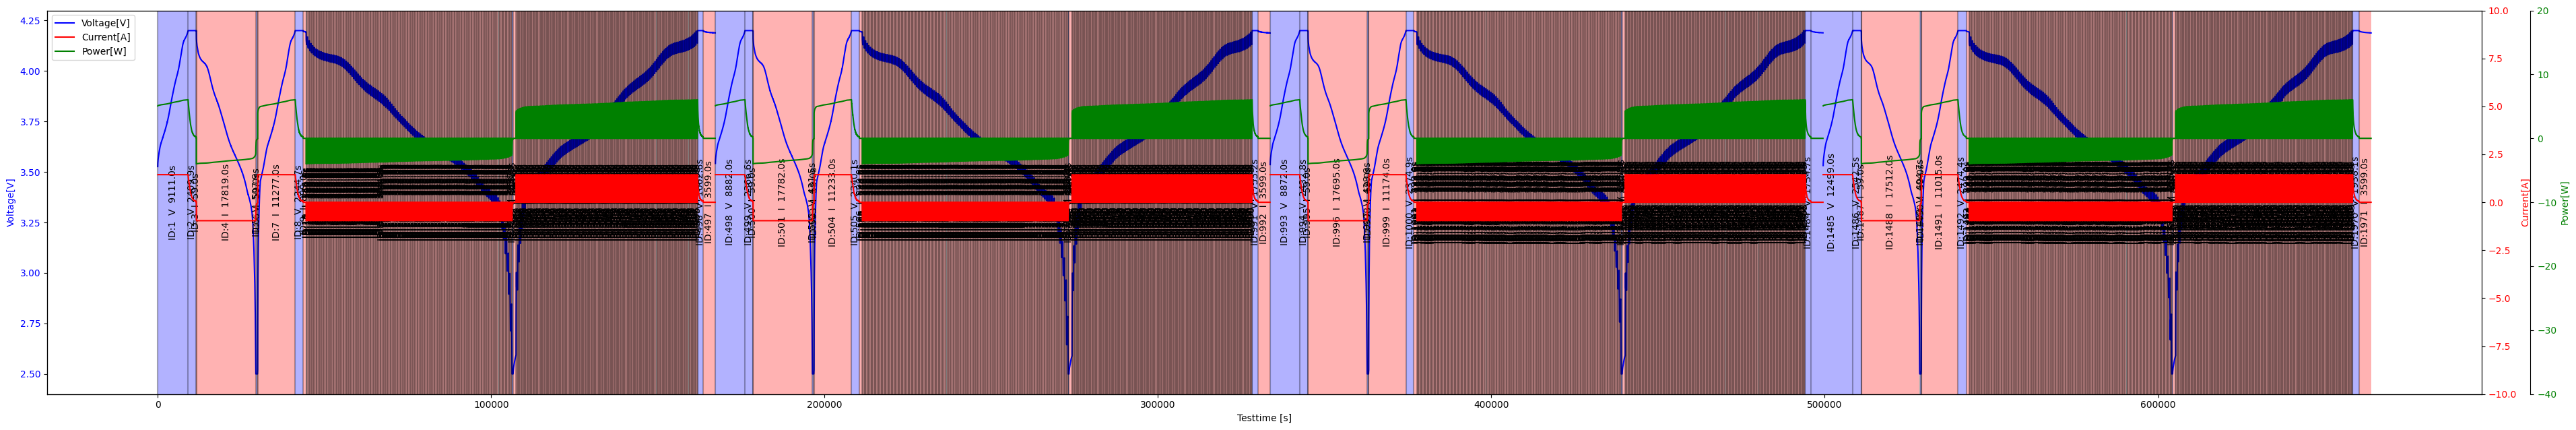

In [9]:
eet.visualize_phases(df=segmented_data, config=eet.VisualizationConfig.DEFAULT)

In [10]:
eet.BatteryConfig.DEFAULT

_BatteryConfigClass(cell_name='Default', c_ref=4.8, soc_start=0, max_voltage=4.2, min_voltage=2.5, threshold_current=0.075, voltage_intervall=0.01, minimal_current_for_capacity=-1.2, maximal_current_for_capacity=-0.8, min_current_diff=0.5, max_time_diff=0.5, min_voltage_diff=0, ignore_negative_resistance_values=False)

## Step 1: add_capacity

In [11]:
df = eet.add_capacity(
    df=standardized_data_merged,
    df_primitives=segmented_data,
    config=eet.BatteryConfig.DEFAULT,
    neware_bool=True,
    verbose=True,
)

In [12]:
added_cols = [c for c in df.columns if c not in standardized_data_merged.columns]
added_cols

['Capacity[Ah]']

<div class="alert alert-block alert-warning">
<b>Warning:</b> Capacity values are only added to the respective datarow at the end of a capacity determination step
</div>

In [13]:
df_filtered = df[df["Capacity[Ah]"].notna()]
df_filtered

,Meta_Data,Step_Count,Voltage[V],Current[A],Temperature[°C],Test_Time[s],Date_Time,EIS_f[Hz],EIS_Z_Real[Ohm],EIS_Z_Imag[Ohm],EIS_DC[A],TestIndex,Capacity[Ah]
29402,None,2.0,2.5033,-0.9599,25.4,29401.9,2024-02-01 18:19:06,None,None,None,None,0.0,4.751879
196463,None,2.0,2.5037,-0.9599,26.0,196354.3,2024-02-23 01:31:07,None,None,None,None,1.0,4.741869
362952,None,2.0,2.5036,-0.9600,26.2,362733.4,2024-04-19 18:10:25,None,None,None,None,2.0,4.719156
528816,None,2.0,2.5036,-0.9599,25.7,528488.4,2024-10-14 17:48:51,None,None,None,None,3.0,4.670351


<Axes: xlabel='Test_Time[s]'>

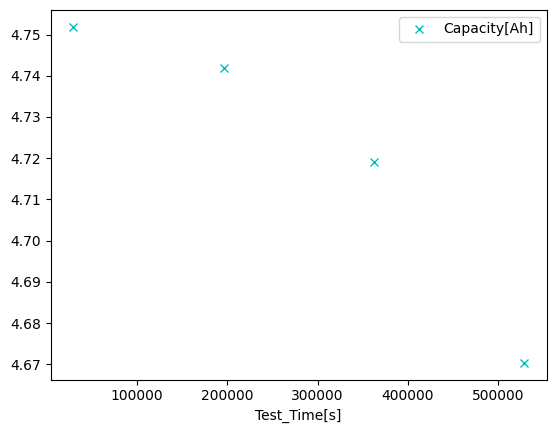

In [14]:
df_filtered.plot(x="Test_Time[s]", y="Capacity[Ah]", style="cx")